<a href="https://colab.research.google.com/github/FunGrape/Labs_Demchyshyn/blob/main/%D0%9A%D0%BE%D0%BD%D1%82%D1%80%D0%BE%D0%BB%D1%8C%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%D0%94%D0%B5%D0%BC%D1%87%D0%B8%D1%88%D0%B8%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== TASK 1 =====
Country
USA        56
India      41
UK         34
Germany    20
Japan      19
France     18
Canada     12
Name: count, dtype: int64
     Title  Country    Views  Uploads
0  Video_0       UK  6042495      417
1  Video_1    Japan  9057842      168
2  Video_2    India  8768088      842
3  Video_3  Germany  6325167       43
4  Video_4      USA   792971      556
Shape: (200, 4)
Missing:
 Title      0
Country    0
Views      0
Uploads    0
dtype: int64
Duplicates: 0
After cleaning:
 Title      0
Country    0
Views      0
Uploads    0
dtype: int64

===== TASK 2 =====
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (tota

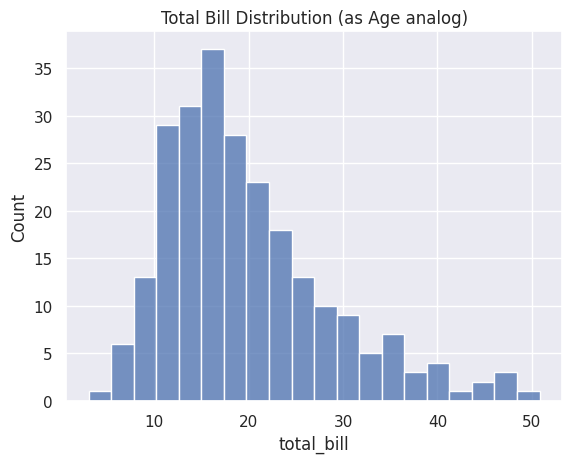

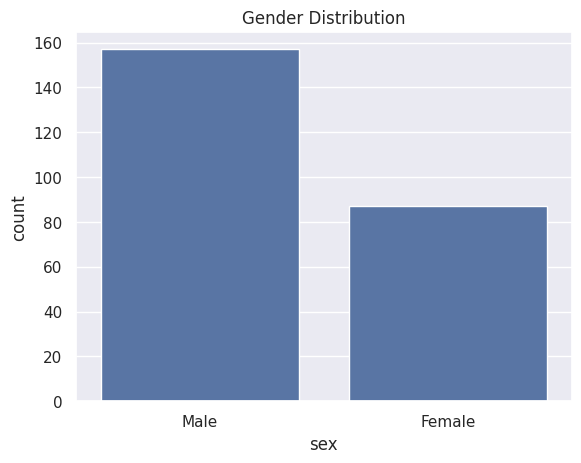

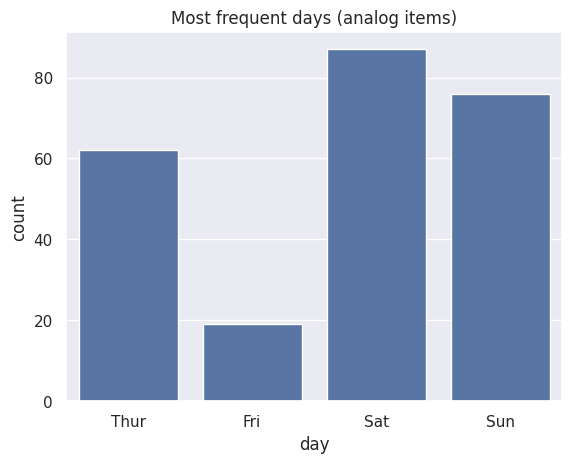

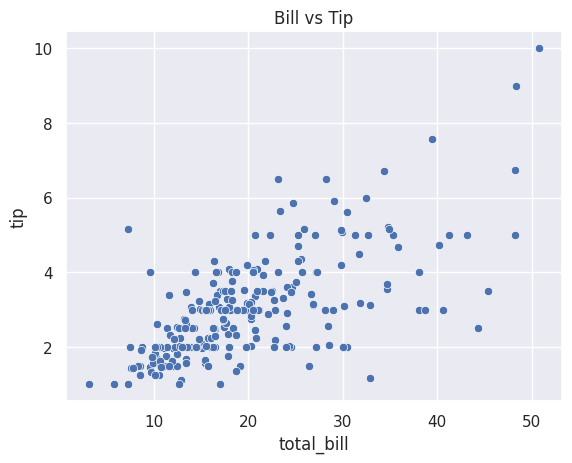

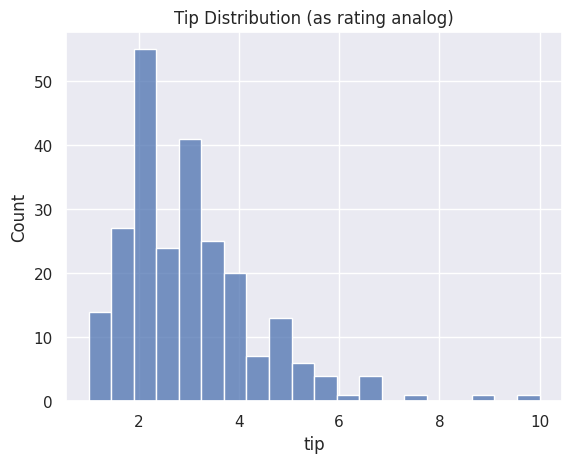

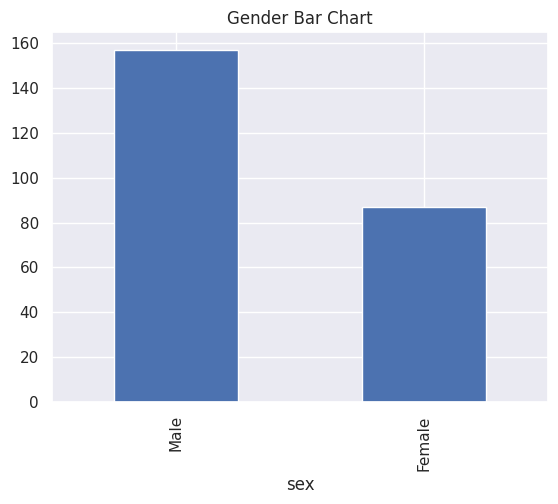

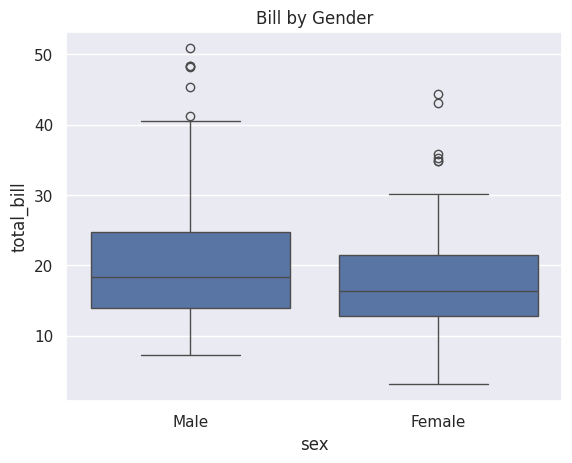

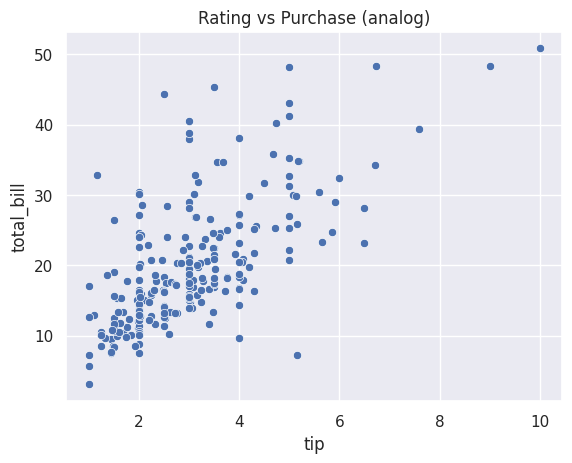


===== TASK 3 =====


alt.LayerChart(...)

alt.Chart(...)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import altair as alt
from vega_datasets import data

sns.set()

# ЗАВДАННЯ 1 (YouTube)

print("TASK 1")
np.random.seed(42)

countries = ["USA", "UK", "Canada", "Germany", "France", "India", "Japan"]

df = pd.DataFrame({
    "Title": [f"Video_{i}" for i in range(200)],
    "Country": np.random.choice(
        countries,
        size=200,
        p=[0.25, 0.15, 0.1, 0.1, 0.1, 0.2, 0.1]
    ),
    "Views": np.random.randint(1000, 10000000, 200),
    "Uploads": np.random.randint(1, 1000, 200)
})

print(df["Country"].value_counts())

# 1-2
print(df.head())

# 3
print("Shape:", df.shape)
print("Missing:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# 4
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

# 5
print("After cleaning:\n", df.isnull().sum())

# (адаптація: у цьому датасеті інші назви)
if 'category' in df.columns:
    print("Unique categories:", df['category'].nunique())

# 7 Гістограма переглядів (views)
if 'views' in df.columns:
    plt.figure()
    sns.histplot(df['views'], bins=30)
    plt.title("Views Distribution")
    plt.show()

# 8
if 'views' in df.columns:
    print("Max:", df['views'].max())
    print("Min:", df['views'].min())
    print("Mean:", df['views'].mean())

# 9-10 (адаптовано)
if 'channel_title' in df.columns:
    print("Top channel:", df['channel_title'].value_counts().idxmax())

# ЗАВДАННЯ 2 (Shopping)

print("\nTASK 2")

df2 = sns.load_dataset("tips")
df2.columns = df2.columns.str.lower().str.replace(" ", "_")

print(df2.head())
print(df2.info())

# 1. Вік (аналог: total_bill)
plt.figure()
sns.histplot(df2['total_bill'], bins=20)
plt.title("Total Bill Distribution (as Age analog)")
plt.show()

# 2. Стать
plt.figure()
sns.countplot(x='sex', data=df2)
plt.title("Gender Distribution")
plt.show()

# 3. Популярність (day)
plt.figure()
sns.countplot(x='day', data=df2)
plt.title("Most frequent days (analog items)")
plt.show()

# 4-5 Scatter
plt.figure()
sns.scatterplot(x='total_bill', y='tip', data=df2)
plt.title("Bill vs Tip")
plt.show()

# 6-7 Рейтинг (аналог: tip)
plt.figure()
sns.histplot(df2['tip'], bins=20)
plt.title("Tip Distribution (as rating analog)")
plt.show()

# 8 Категоріальна
df2['sex'].value_counts().plot(kind='bar')
plt.title("Gender Bar Chart")
plt.show()

# 9 Boxplot
plt.figure()
sns.boxplot(x='sex', y='total_bill', data=df2)
plt.title("Bill by Gender")
plt.show()

# 10 Scatter
plt.figure()
sns.scatterplot(x='tip', y='total_bill', data=df2)
plt.title("Rating vs Purchase (analog)")
plt.show()

# ЗАВДАННЯ 3

print("\n===== TASK 3 =====")

# 1. Wheat (Altair)
wheat = data.wheat()

chart = alt.Chart(wheat).mark_bar().encode(
    x='wheat:Q',
    y='year:O'
)

text = chart.mark_text(dx=3).encode(text='wheat:Q')

(chart + text).display()

# 2. Iowa electricity
iowa = data.iowa_electricity()

alt.Chart(iowa).mark_area(opacity=0.7).encode(
    x='year:T',
    y='net_generation:Q',
    color='source:N'
).display()

# 3. Iris (Plotly)
iris = px.data.iris()

fig = px.scatter(
    iris,
    x="sepal_width",
    y="sepal_length",
    size="petal_length",
    color="species",
    hover_data=["petal_width"],
    title="Iris Dataset"
)

fig.show()